# Replicate DEG Metric Violins

This notebook only reads the Slurm-precomputed replicate DEG outputs and plots per-dataset violins. Summary tables below each plot report observed and baseline means/medians.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "results" / "replicate_signature_similarity_sep_rep_combined"
DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "tahoe",
    "cigs_mce",
    "novartis_batch_1000",
    "vcpi_0001",
    "cigs_tcm",
    "vcpi_0002",
    "gdpx2",
    "sciplex",
    "dilimap_train_val",
    "op3",
]
PRETTY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "tahoe": "Tahoe-100M",
    "cigs_mce": "CIGS-MCE",
    "novartis_batch_1000": "Novartis/DRUG-seq U2OS",
    "vcpi_0001": "VCPI-0001",
    "cigs_tcm": "CIGS-TCM",
    "vcpi_0002": "VCPI-0002",
    "gdpx2": "GDPx2",
    "sciplex": "sci-Plex",
    "dilimap_train_val": "DILImap",
    "op3": "OP3",
}
DATASET_ORDER_MAP = {dataset_name: idx for idx, dataset_name in enumerate(DATASET_ORDER)}

sns.set_theme(style="whitegrid", context="talk")


def pretty_label(dataset_name: str) -> str:
    return PRETTY_LABELS.get(str(dataset_name), str(dataset_name))


def dataset_names_in_order(frame: pd.DataFrame) -> list[str]:
    present = set(frame["dataset_name"].dropna().astype(str).unique().tolist())
    ordered = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in present]
    ordered.extend(sorted(dataset_name for dataset_name in present if dataset_name not in DATASET_ORDER_MAP))
    return ordered


def dataset_label_order(frame: pd.DataFrame) -> list[str]:
    return [pretty_label(dataset_name) for dataset_name in dataset_names_in_order(frame)]


def sort_by_dataset_order(frame: pd.DataFrame) -> pd.DataFrame:
    sort_frame = frame.copy()
    sort_frame["_dataset_order"] = sort_frame["dataset_name"].astype(str).map(DATASET_ORDER_MAP).fillna(len(DATASET_ORDER))
    return (
        sort_frame.sort_values(["_dataset_order", "dataset_name"])
        .drop(columns="_dataset_order")
        .reset_index(drop=True)
    )


def validate_condition_metric_counts(condition_frame: pd.DataFrame, dataset_summary: pd.DataFrame, *, condition_summary_name: str) -> pd.DataFrame:
    missing_condition_columns = sorted({"dataset_name", "condition_key"} - set(condition_frame.columns))
    if missing_condition_columns:
        raise KeyError(f"Missing columns in {condition_summary_name}: {missing_condition_columns}")
    missing_dataset_columns = sorted({"dataset_name", "n_conditions"} - set(dataset_summary.columns))
    if missing_dataset_columns:
        raise KeyError(f"Missing columns in dataset summary: {missing_dataset_columns}")

    expected = dataset_summary[["dataset_name", "n_conditions"]].copy()
    expected["dataset_name"] = expected["dataset_name"].astype(str)
    expected["expected_n_conditions"] = pd.to_numeric(expected["n_conditions"], errors="raise").round().astype(int)
    expected = expected[["dataset_name", "expected_n_conditions"]]

    observed_source = condition_frame[["dataset_name"]].copy()
    observed_source["dataset_name"] = observed_source["dataset_name"].astype(str)
    observed = observed_source.groupby("dataset_name").size().rename("observed_n_conditions").reset_index()

    comparison = expected.merge(observed, on="dataset_name", how="outer")
    comparison[["expected_n_conditions", "observed_n_conditions"]] = (
        comparison[["expected_n_conditions", "observed_n_conditions"]].fillna(0).astype(int)
    )
    comparison = sort_by_dataset_order(comparison)
    mismatches = comparison.loc[comparison["expected_n_conditions"] != comparison["observed_n_conditions"]]
    if not mismatches.empty:
        raise ValueError(
            f"{condition_summary_name} does not match the merged dataset summary. "
            "This usually means one of the combined output files is stale.\n"
            + mismatches.to_string(index=False)
        )
    return comparison


def plot_violin_with_baseline(frame: pd.DataFrame, *, observed_col: str, baseline_col: str, title: str, ylabel: str, pdf_name: str) -> pd.DataFrame:
    required_columns = {"dataset_name", "condition_key", observed_col, baseline_col}
    missing = sorted(required_columns - set(frame.columns))
    if missing:
        raise KeyError(f"Missing columns for plot {title!r}: {missing}")

    plot_frame = frame[["dataset_name", "condition_key", observed_col, baseline_col]].copy()
    plot_frame = plot_frame.rename(columns={observed_col: "observed", baseline_col: "baseline"})
    plot_frame["dataset_label"] = plot_frame["dataset_name"].map(pretty_label)
    plot_frame = plot_frame.loc[plot_frame["observed"].notna()].copy()
    if plot_frame.empty:
        raise ValueError(f"No observed values available for plot {title!r}.")

    order = dataset_label_order(plot_frame)
    fig_width = max(10.0, 1.35 * len(order) + 2.0)
    fig, ax = plt.subplots(figsize=(fig_width, 6.4))

    baseline_frame = plot_frame.loc[plot_frame["baseline"].notna()].copy()
    baseline_count_by_dataset = baseline_frame.groupby("dataset_name")["condition_key"].nunique() if not baseline_frame.empty else pd.Series(dtype=int)
    observed_violin_frame = plot_frame[["dataset_name", "dataset_label", "condition_key", "observed"]].rename(columns={"observed": "score"})
    observed_violin_frame["score_type"] = "Cross replicate"
    baseline_violin_frame = baseline_frame[["dataset_name", "dataset_label", "condition_key", "baseline"]].rename(columns={"baseline": "score"})
    baseline_violin_frame["score_type"] = "Baseline"
    violin_frame = pd.concat([observed_violin_frame, baseline_violin_frame], ignore_index=True)
    hue_order = ["Cross replicate", "Baseline"] if not baseline_violin_frame.empty else ["Cross replicate"]

    sns.violinplot(
        data=violin_frame,
        x="dataset_label",
        y="score",
        hue="score_type",
        order=order,
        hue_order=hue_order,
        inner=None,
        cut=0,
        linewidth=1.0,
        palette={"Cross replicate": "#dbe9f6", "Baseline": "#f4c7c3"},
        dodge=True,
        ax=ax,
    )

    summary = plot_frame.groupby(["dataset_name", "dataset_label"], as_index=False).agg(
        n_conditions=("condition_key", "nunique"),
        observed_mean=("observed", "mean"),
        observed_median=("observed", "median"),
        baseline_mean=("baseline", "mean"),
        baseline_median=("baseline", "median"),
    )
    summary = sort_by_dataset_order(summary)
    summary["n_conditions_with_baseline"] = summary["dataset_name"].map(baseline_count_by_dataset).fillna(0).astype(int)
    if ax.get_legend() is not None:
        ax.legend(title="", loc="best", frameon=True)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=35)
    sns.despine(ax=ax)
    fig.tight_layout()
    out_path = RESULTS_DIR / pdf_name
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out_path}")
    zero_baseline = summary.loc[summary["n_conditions_with_baseline"] == 0, "dataset_label"].tolist()
    if zero_baseline:
        print("No baseline-scored conditions in:", ", ".join(zero_baseline))
    display(summary)
    return summary


def plot_summary_heatmap(
    summary: pd.DataFrame,
    *,
    title: str,
    value_label: str,
    pdf_name: str,
    vmin=None,
    vmax=None,
    show_colorbar: bool = True,
    show_dataset_labels: bool = True,
) -> pd.DataFrame:
    required_columns = {"dataset_name", "dataset_label", "observed_mean", "baseline_mean"}
    missing = sorted(required_columns - set(summary.columns))
    if missing:
        raise KeyError(f"Missing columns for heatmap {title!r}: {missing}")

    summary_frame = summary.copy()
    summary_frame["delta_mean"] = summary_frame["observed_mean"] - summary_frame["baseline_mean"]
    summary_frame = sort_by_dataset_order(summary_frame)

    heatmap_frame = summary_frame[["dataset_label", "observed_mean", "baseline_mean", "delta_mean"]].rename(
        columns={
            "dataset_label": "Dataset",
            "observed_mean": "Mean observed",
            "baseline_mean": "Mean baseline",
            "delta_mean": "Mean observed - baseline",
        }
    ).set_index("Dataset")

    fig, ax = plt.subplots(figsize=(8.6, max(4.5, 1.0 * len(heatmap_frame))))
    sns.heatmap(
        heatmap_frame,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0.0,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar=show_colorbar,
        cbar_kws={"label": value_label} if show_colorbar else {},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    if show_dataset_labels:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.tick_params(axis="y", labelleft=False, length=0)
    fig.tight_layout()
    out_path = RESULTS_DIR / pdf_name
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {out_path}")
    display(heatmap_frame)
    return heatmap_frame


def shared_summary_heatmap_limits(*summaries: pd.DataFrame) -> tuple[float, float]:
    values = []
    for summary in summaries:
        summary_frame = summary.copy()
        summary_frame["delta_mean"] = summary_frame["observed_mean"] - summary_frame["baseline_mean"]
        values.append(summary_frame[["observed_mean", "baseline_mean", "delta_mean"]].stack())
    all_values = pd.concat(values).dropna()
    if all_values.empty:
        raise ValueError("No finite values available for shared heatmap limits.")
    return float(all_values.min()), float(all_values.max())


In [2]:
import json

task_config_path = RESULTS_DIR / 'task_inputs' / 'task_config.json'
if not task_config_path.exists():
    raise FileNotFoundError(f'Missing task config: {task_config_path}')
with task_config_path.open() as handle:
    task_config = json.load(handle)
if not bool(task_config.get('compute_deg_metrics', False)):
    raise ValueError(
        'The current prepare outputs were created without DEG metrics enabled. '
        'Rerun the Slurm workflow from stage 1 with COMPUTE_DEG_METRICS=1.'
    )
if not bool(task_config.get('compute_baseline_metrics', False)):
    raise ValueError(
        'The current prepare outputs were created without baseline metrics enabled. '
        'Rerun the Slurm workflow from stage 1 with COMPUTE_BASELINE_METRICS=1.'
    )

condition_deg_metric_summary = pd.read_csv(RESULTS_DIR / 'condition_deg_metric_summary.tsv', sep='	')
dataset_deg_metric_summary = pd.read_csv(RESULTS_DIR / 'dataset_deg_metric_summary.tsv', sep='	')
condition_deg_metric_counts = validate_condition_metric_counts(
    condition_deg_metric_summary,
    dataset_deg_metric_summary,
    condition_summary_name='condition_deg_metric_summary.tsv',
)
required_direction_cols = [
    'mean_replicate_direction_agreement_p05',
    'mean_baseline_pair_direction_agreement_p05',
]
missing_direction_cols = [column_name for column_name in required_direction_cols if column_name not in condition_deg_metric_summary.columns]
if missing_direction_cols:
    condition_metric_summary = pd.read_csv(RESULTS_DIR / 'condition_metric_summary.tsv', sep='	')
    merge_keys = ['dataset_name', 'condition_key']
    available_merge_columns = [
        column_name
        for column_name in required_direction_cols
        if column_name in condition_metric_summary.columns
    ]
    if all(column_name in condition_metric_summary.columns for column_name in merge_keys) and available_merge_columns:
        condition_deg_metric_summary = condition_deg_metric_summary.merge(
            condition_metric_summary[merge_keys + available_merge_columns].drop_duplicates(merge_keys),
            on=merge_keys,
            how='left',
        )
print(
    f"Loaded {len(condition_deg_metric_summary):,} DEG condition rows across "
    f"{condition_deg_metric_summary['dataset_name'].nunique():,} datasets from {RESULTS_DIR}."
)
display(condition_deg_metric_counts)
condition_deg_metric_summary.head()


Loaded 82,494 DEG condition rows across 12 datasets from /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined.


,dataset_name,expected_n_conditions,observed_n_conditions
0,l1000_phase1,1504,1504
1,l1000_phase2,1921,1921
2,tahoe,7226,7226
3,cigs_mce,21426,21426
4,novartis_batch_1000,15276,15276
5,vcpi_0001,13283,13283
6,cigs_tcm,7020,7020
7,vcpi_0002,8825,8825
8,gdpx2,2064,2064
9,sciplex,2224,2224


,dataset_name,cell_type,pubchem_cid,time_key,dose_key,condition_key,perturbagen_display,n_replicates,n_replicate_pairs,n_source_files,...,median_replicate_de_overlap_k200_p05,median_replicate_de_overlap_k200_p05_lfc02,median_replicate_de_overlap_k50_p05,median_replicate_de_overlap_k50_p05_lfc02,median_replicate_de_overlap_refn_sym_p05,median_replicate_de_overlap_refn_sym_p05_lfc02,median_replicate_deg_lfc_spearman_sym_p05,median_replicate_deg_lfc_spearman_sym_p05_lfc02,median_replicate_direction_agreement_p05,median_replicate_direction_agreement_p05_lfc02
0,cigs_mce,CVCL_0062,7,24,10.0,CVCL_0062|7|24|10,9-Ethyladenine,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cigs_mce,CVCL_0062,19,24,10.0,CVCL_0062|19|24|10,Pyrocatechuic acid,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cigs_mce,CVCL_0062,47,24,10.0,CVCL_0062|47|24|10,3-Methyl-2-oxovaleric acid,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cigs_mce,CVCL_0062,49,24,10.0,CVCL_0062|49|24|10,3-Methyl-2-oxobutanoic acid,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cigs_mce,CVCL_0062,58,24,10.0,CVCL_0062|58|24|10,2-Oxobutanoic acid,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

deg_ci_metrics = {
    "observed_deg_lfc_spearman_sym_p05": "mean_replicate_deg_lfc_spearman_sym_p05",
    "baseline_pair_deg_lfc_spearman_sym_p05": "mean_baseline_pair_deg_lfc_spearman_sym_p05",
    "delta_vs_baseline_pair_deg_lfc_spearman_sym_p05": "mean_delta_vs_baseline_pair_deg_lfc_spearman_sym_p05",
    "observed_direction_agreement_p05": "mean_replicate_direction_agreement_p05",
    "baseline_pair_direction_agreement_p05": "mean_baseline_pair_direction_agreement_p05",
    "delta_vs_baseline_pair_direction_agreement_p05": "mean_delta_vs_baseline_pair_direction_agreement_p05",
}

replicate_deg_cluster_bca_ci = cluster_bca_nested_mean_ci_table(
    condition_deg_metric_summary,
    group_cols=["dataset_name"],
    metric_cols=deg_ci_metrics,
    cluster_col="pubchem_cid",
    n_boot=BOOTSTRAP_ITERATIONS,
    seed=BOOTSTRAP_RANDOM_SEED,
    summary_level="dataset",
)
replicate_deg_cluster_bca_ci = sort_by_dataset_order(replicate_deg_cluster_bca_ci)
replicate_deg_cluster_bca_ci_path = RESULTS_DIR / "replicate_deg_metric_cluster_bca_ci.tsv"
replicate_deg_cluster_bca_ci.to_csv(replicate_deg_cluster_bca_ci_path, sep="\t", index=False)
print(f"Saved replicate DEG cluster-BCa CI table to {replicate_deg_cluster_bca_ci_path}")

replicate_deg_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(replicate_deg_cluster_bca_ci)
replicate_deg_cluster_bca_ci_ranges_path = RESULTS_DIR / "replicate_deg_metric_cluster_bca_ci_ranges.tsv"
replicate_deg_cluster_bca_ci_ranges.to_csv(replicate_deg_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved replicate DEG CI half-width ranges to {replicate_deg_cluster_bca_ci_ranges_path}")
display(replicate_deg_cluster_bca_ci)
display(replicate_deg_cluster_bca_ci_ranges)


Saved replicate DEG cluster-BCa CI table to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_deg_metric_cluster_bca_ci.tsv
Saved replicate DEG CI half-width ranges to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_deg_metric_cluster_bca_ci_ranges.tsv


,dataset_name,summary_level,metric,value_col,mean,ci_low,ci_high,ci_half_width,ci_method,ci_status,ci_level,n_bootstrap_iterations,n_bootstrap_valid,n_rows,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope
0,l1000_phase1,dataset,observed_deg_lfc_spearman_sym_p05,mean_replicate_deg_lfc_spearman_sym_p05,0.095926,0.057449,0.154122,0.048337,bca,ok,0.95,2000,2000,1504,1448,176,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
1,l1000_phase1,dataset,baseline_pair_deg_lfc_spearman_sym_p05,mean_baseline_pair_deg_lfc_spearman_sym_p05,0.219524,0.193126,0.247179,0.027027,bca,ok,0.95,2000,2000,1504,1421,176,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
2,l1000_phase1,dataset,delta_vs_baseline_pair_deg_lfc_spearman_sym_p05,mean_delta_vs_baseline_pair_deg_lfc_spearman_s...,-0.129868,-0.160307,-0.089484,0.035412,bca,ok,0.95,2000,2000,1504,1372,175,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
3,l1000_phase1,dataset,observed_direction_agreement_p05,mean_replicate_direction_agreement_p05,0.863669,0.840113,0.884969,0.022428,bca,ok,0.95,2000,2000,1504,1066,170,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
4,l1000_phase1,dataset,baseline_pair_direction_agreement_p05,mean_baseline_pair_direction_agreement_p05,0.625806,0.613260,0.638486,0.012613,bca,ok,0.95,2000,2000,1504,1424,176,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,op3,dataset,baseline_pair_deg_lfc_spearman_sym_p05,mean_baseline_pair_deg_lfc_spearman_sym_p05,0.391289,0.315193,0.455190,0.069999,bca,ok,0.95,2000,2000,541,332,121,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
68,op3,dataset,delta_vs_baseline_pair_deg_lfc_spearman_sym_p05,mean_delta_vs_baseline_pair_deg_lfc_spearman_s...,0.181896,0.122927,0.250809,0.063941,bca,ok,0.95,2000,2000,541,227,88,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
69,op3,dataset,observed_direction_agreement_p05,mean_replicate_direction_agreement_p05,0.998388,0.994750,0.999449,0.002350,bca,ok,0.95,2000,2000,541,209,78,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...
70,op3,dataset,baseline_pair_direction_agreement_p05,mean_baseline_pair_direction_agreement_p05,0.731487,0.690472,0.767049,0.038288,bca,ok,0.95,2000,2000,541,409,135,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset,baseline_pair_deg_lfc_spearman_sym_p05,12,0.008192,0.023690,0.069999,86,9096,bca,ok
1,dataset,baseline_pair_direction_agreement_p05,12,0.003768,0.010939,0.038288,86,10310,bca,ok
2,dataset,delta_vs_baseline_pair_deg_lfc_spearman_sym_p05,12,0.010591,0.031534,0.063941,86,5007,bca,ok
3,dataset,delta_vs_baseline_pair_direction_agreement_p05,12,0.005536,0.016731,0.045579,78,4065,bca,ok
4,dataset,observed_deg_lfc_spearman_sym_p05,12,0.009453,0.042536,0.077918,86,5007,bca,ok
5,dataset,observed_direction_agreement_p05,12,0.000000,0.003014,0.055854,78,4065,"bca,degenerate","ok,zero_bootstrap_variance"


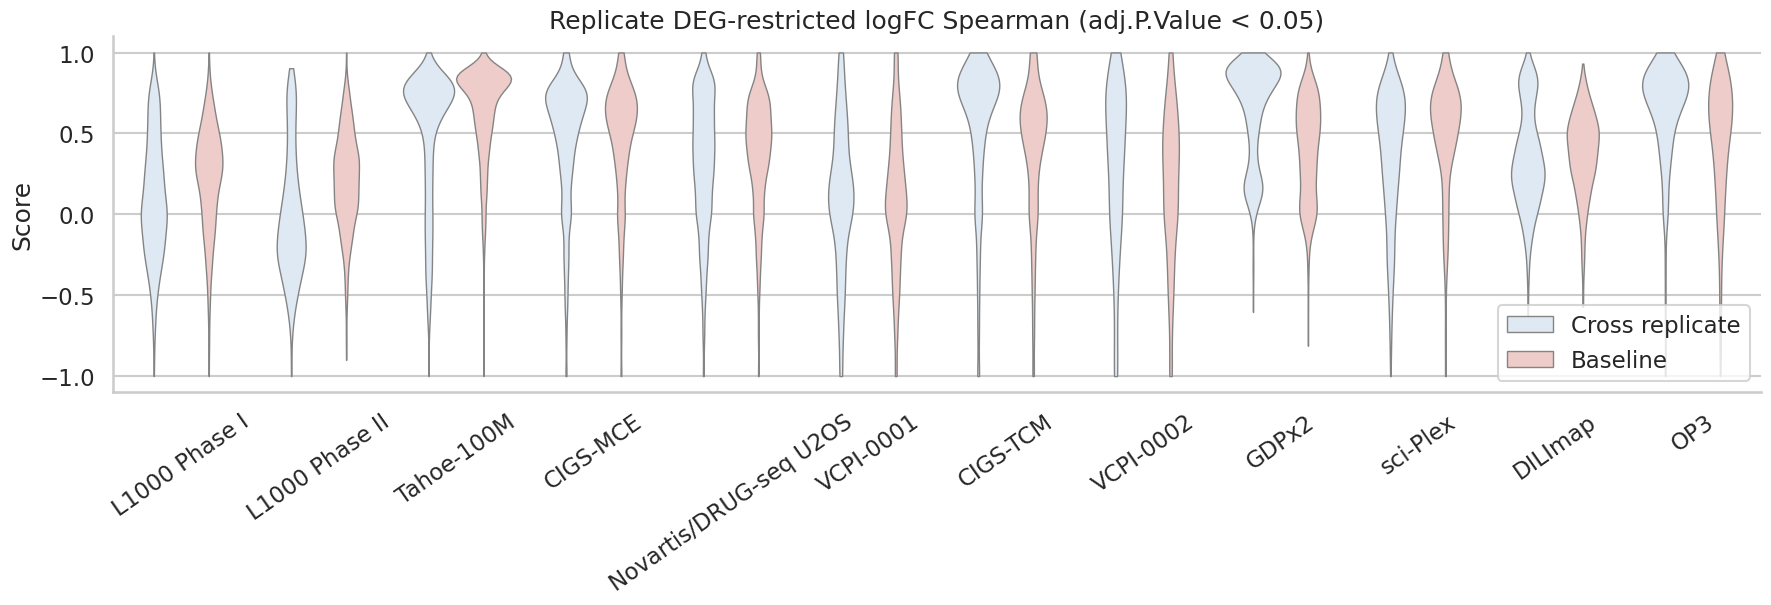

Saved plot to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_deg_lfc_spearman_p05_violin.pdf


,dataset_name,dataset_label,n_conditions,observed_mean,observed_median,baseline_mean,baseline_median,n_conditions_with_baseline
0,l1000_phase1,L1000 Phase I,1448,0.095926,0.064612,0.223998,0.271457,1372
1,l1000_phase2,L1000 Phase II,1894,-0.004192,-0.085330,0.208599,0.217255,1891
2,tahoe,Tahoe-100M,6240,0.481157,0.669102,0.633600,0.737613,6240
3,cigs_mce,CIGS-MCE,6368,0.454122,0.580388,0.461264,0.559029,6368
4,novartis_batch_1000,Novartis/DRUG-seq U2OS,9395,0.319676,0.371234,0.367892,0.430506,9395
5,vcpi_0001,VCPI-0001,1980,0.114960,0.127201,0.108548,0.100000,1980
6,cigs_tcm,CIGS-TCM,1720,0.543602,0.713830,0.383943,0.500000,1720
7,vcpi_0002,VCPI-0002,552,0.295481,0.400000,0.175948,0.250000,552
8,gdpx2,GDPx2,1086,0.643370,0.776421,0.390917,0.435905,1086
9,sciplex,sci-Plex,708,0.354706,0.465679,0.474043,0.571802,708


In [4]:
deg_lfc_summary = plot_violin_with_baseline(
    condition_deg_metric_summary,
    observed_col='mean_replicate_deg_lfc_spearman_sym_p05',
    baseline_col='mean_baseline_pair_deg_lfc_spearman_sym_p05',
    title='Replicate DEG-restricted logFC Spearman (adj.P.Value < 0.05)',
    ylabel='Score',
    pdf_name='replicate_deg_lfc_spearman_p05_violin.pdf',
)

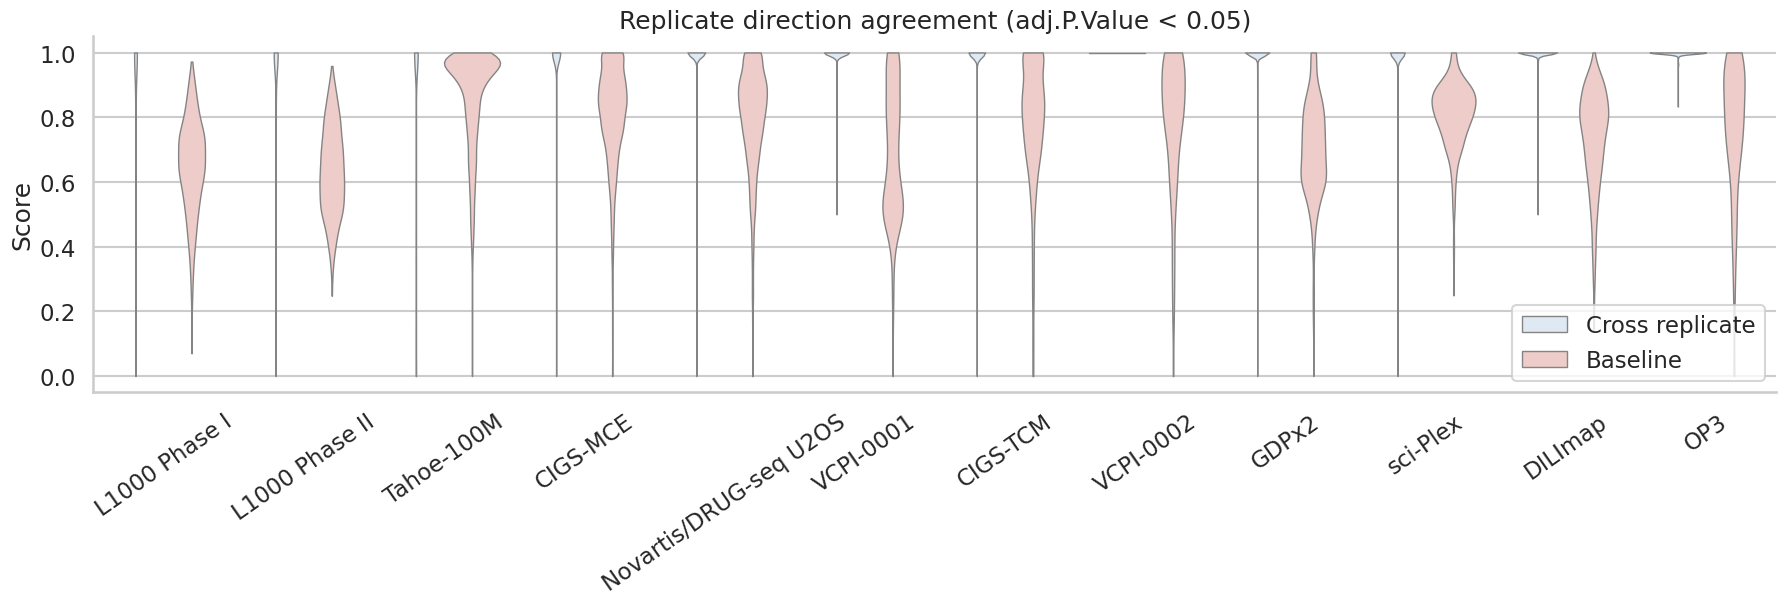

Saved plot to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_direction_agreement_p05_violin.pdf


,dataset_name,dataset_label,n_conditions,observed_mean,observed_median,baseline_mean,baseline_median,n_conditions_with_baseline
0,l1000_phase1,L1000 Phase I,1066,0.863669,1.0,0.649463,0.659470,1009
1,l1000_phase2,L1000 Phase II,1305,0.910286,1.0,0.635148,0.628571,1302
2,tahoe,Tahoe-100M,5849,0.859374,1.0,0.857525,0.921134,5849
3,cigs_mce,CIGS-MCE,5222,0.963681,1.0,0.807472,0.833333,5222
4,novartis_batch_1000,Novartis/DRUG-seq U2OS,8048,0.989447,1.0,0.789407,0.825000,8048
5,vcpi_0001,VCPI-0001,637,0.995876,1.0,0.689336,0.669183,637
6,cigs_tcm,CIGS-TCM,1687,0.994767,1.0,0.783738,0.818687,1687
7,vcpi_0002,VCPI-0002,343,1.000000,1.0,0.786335,0.833333,343
8,gdpx2,GDPx2,1090,0.995744,1.0,0.700033,0.700102,1090
9,sciplex,sci-Plex,360,0.995554,1.0,0.803052,0.825264,360


In [5]:
direction_summary = plot_violin_with_baseline(
    condition_deg_metric_summary,
    observed_col='mean_replicate_direction_agreement_p05',
    baseline_col='mean_baseline_pair_direction_agreement_p05',
    title='Replicate direction agreement (adj.P.Value < 0.05)',
    ylabel='Score',
    pdf_name='replicate_direction_agreement_p05_violin.pdf',
)

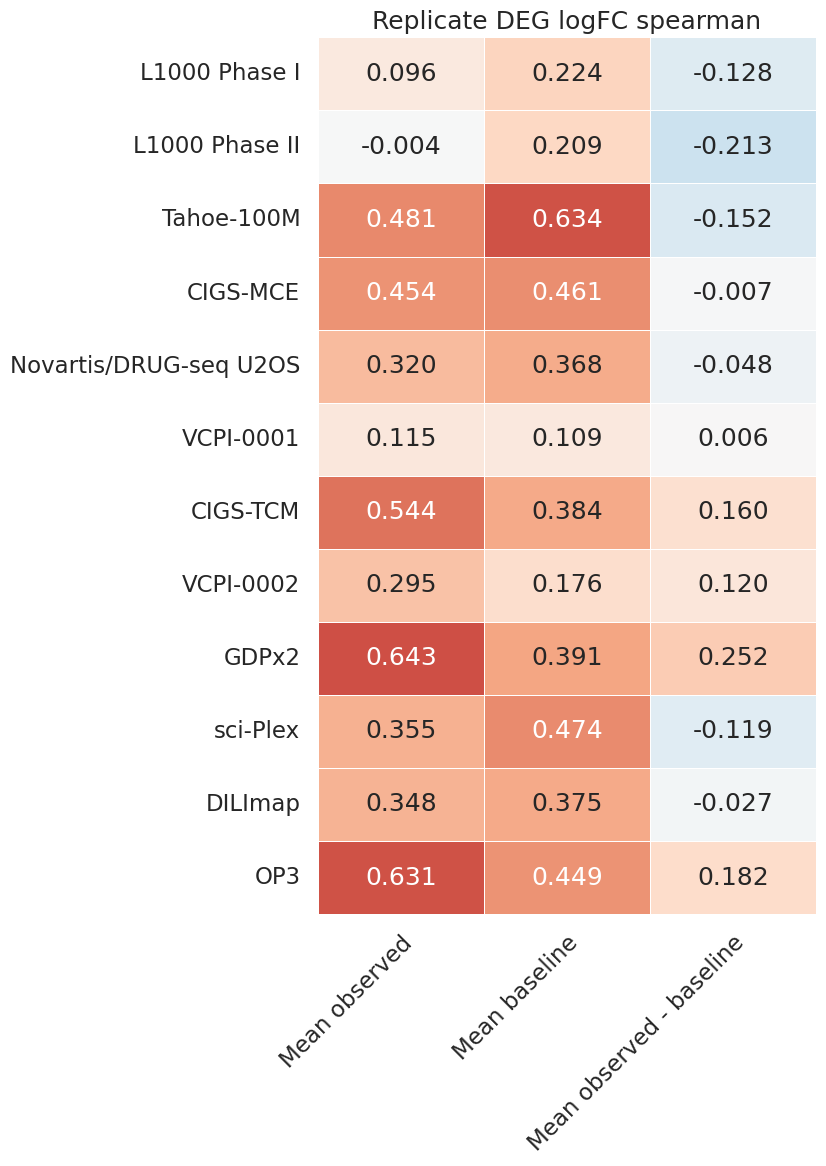

Saved heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_deg_lfc_spearman_p05_heatmap.pdf


,Mean observed,Mean baseline,Mean observed - baseline
Dataset,,,
L1000 Phase I,0.095926,0.223998,-0.128072
L1000 Phase II,-0.004192,0.208599,-0.212791
Tahoe-100M,0.481157,0.633600,-0.152443
CIGS-MCE,0.454122,0.461264,-0.007142
Novartis/DRUG-seq U2OS,0.319676,0.367892,-0.048216
VCPI-0001,0.114960,0.108548,0.006412
CIGS-TCM,0.543602,0.383943,0.159659
VCPI-0002,0.295481,0.175948,0.119532
GDPx2,0.643370,0.390917,0.252453


In [6]:
# Heatmap: DEG logFC Spearman
shared_heatmap_vmin, shared_heatmap_vmax = shared_summary_heatmap_limits(deg_lfc_summary, direction_summary)

deg_lfc_heatmap = plot_summary_heatmap(
    deg_lfc_summary,
    title='Replicate DEG logFC spearman',
    value_label='',
    pdf_name='replicate_deg_lfc_spearman_p05_heatmap.pdf',
    vmin=shared_heatmap_vmin,
    vmax=shared_heatmap_vmax,
    show_colorbar=False,
)

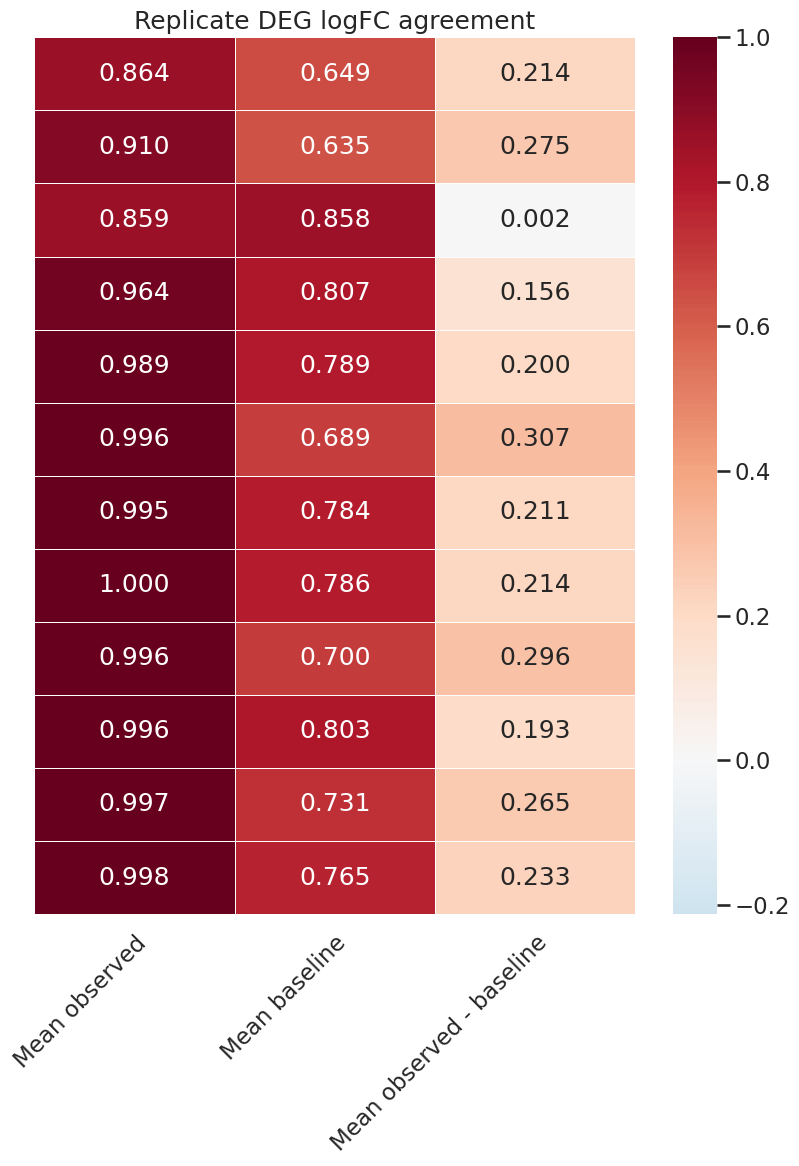

Saved heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/replicate_signature_similarity_sep_rep_combined/replicate_direction_agreement_p05_heatmap.pdf


,Mean observed,Mean baseline,Mean observed - baseline
Dataset,,,
L1000 Phase I,0.863669,0.649463,0.214207
L1000 Phase II,0.910286,0.635148,0.275138
Tahoe-100M,0.859374,0.857525,0.001848
CIGS-MCE,0.963681,0.807472,0.156209
Novartis/DRUG-seq U2OS,0.989447,0.789407,0.200039
VCPI-0001,0.995876,0.689336,0.306540
CIGS-TCM,0.994767,0.783738,0.211029
VCPI-0002,1.000000,0.786335,0.213665
GDPx2,0.995744,0.700033,0.295711


In [7]:
# Heatmap: direction agreement
direction_heatmap = plot_summary_heatmap(
    direction_summary,
    title='Replicate DEG logFC agreement',
    value_label='',
    pdf_name='replicate_direction_agreement_p05_heatmap.pdf',
    vmin=shared_heatmap_vmin,
    vmax=shared_heatmap_vmax,
    show_dataset_labels=False,
)